In [54]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import os
from tensorflow import keras
from tensorflow.keras import layers
from IPython.display import display

In [55]:
CSV_PATH = "/kaggle/input/datasets/solarmainframe/ids-intrusion-csv/02-21-2018.csv" 
#SAMPLE_SIZE = len(pd.read_csv(CSV_PATH, usecols=[0]))
SAMPLE_SIZE=100000 
print(SAMPLE_SIZE)
BATCH_SIZE = 512
EPOCHS = 25
LEARNING_RATE = 1e-4


D_TOKEN = 192          
N_BLOCKS = 3           
ATTENTION_HEADS = 8    
DROPOUT = 0.1

100000


In [56]:
def load_and_clean_data(csv_path, sample_size=None):
    print(f"Loading data from {csv_path}...")
    
    df = pd.read_csv(csv_path, low_memory=False)
    display(df.describe())
   
    df = df[df['Dst Port'] != 'Dst Port']
    
    
    cols_to_numeric = df.columns.drop('Label')
    df[cols_to_numeric] = df[cols_to_numeric].apply(pd.to_numeric, errors='coerce')
    
    
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    
    df.dropna(axis=1, how='all', inplace=True) 
    
    print("Replacing NaN values with the mean of the column (Imputation)...")
    for col in df.columns.drop('Label'):
        if df[col].isnull().any():
            df[col].fillna(df[col].mean(), inplace=True)
            

    df.dropna(inplace=True)

    
    if sample_size and sample_size < len(df):
        print(f"Sampling {sample_size} records...")
        df = df.sample(n=sample_size, random_state=42)
        
    print(f"Data Loaded. Final Shape: {df.shape}")
    print(f"Class distribution:\n{df['Label'].value_counts()}")
    
    return df

In [57]:
path = CSV_PATH


full_cleaned_df = load_and_clean_data(path, sample_size=None)

print(f"Total cleaned rows available: {len(full_cleaned_df):,}")


df_check = full_cleaned_df.sample(n=100000, random_state=42)


leftover_df = full_cleaned_df.drop(df_check.index)


del full_cleaned_df 

features = df_check.columns.drop('Label')
    
print(f"File: {path}")
print(f"Number of Features: {len(features)}")
print(f"Feature Names: {list(features)}")
print("-" * 50)


print(f"Sampled Data (Going to model): {len(df_check):,} rows")
print(f"Leftover Data (Saved for end): {len(leftover_df):,} rows")

Loading data from /kaggle/input/datasets/solarmainframe/ids-intrusion-csv/02-21-2018.csv...


,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,...,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,...,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,1.958764e+04,6.037952e+00,3.990401e+05,1.968099e+02,1.309663e+00,6.563581e+03,2.486527e+02,3.666938e+02,2.549479e-01,7.977144e+01,...,1.941294e+02,1.995892e+01,7.521672e+03,2.589427e+03,1.003609e+04,5.446253e+03,3.140514e+04,1.602645e+04,5.723070e+04,1.633481e+04
std,2.719338e+04,6.495848e-01,6.630337e+06,4.899047e+03,1.477423e+00,1.567596e+05,3.257857e+02,4.226960e+02,8.978105e+00,8.511139e+01,...,4.899113e+03,7.395666e-01,2.033449e+05,1.034448e+05,2.825239e+05,1.568789e+05,8.419967e+05,4.340229e+05,1.421182e+06,5.894628e+05
min,0.000000e+00,0.000000e+00,2.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,8.000000e+01,6.000000e+00,1.408000e+03,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,6.000000e+00,4.720000e+03,3.000000e+00,0.000000e+00,2.470000e+02,0.000000e+00,3.200000e+01,0.000000e+00,3.200000e+01,...,1.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,5.355300e+04,6.000000e+00,1.464900e+04,5.000000e+00,2.000000e+00,9.350000e+02,3.160000e+02,9.350000e+02,0.000000e+00,1.870000e+02,...,1.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553400e+04,1.700000e+01,1.200000e+08,3.096290e+05,1.240000e+02,9.908128e+06,9.121000e+03,2.224000e+03,9.760000e+02,9.760000e+02,...,3.096280e+05,4.400000e+01,2.000000e+07,1.620000e+07,2.800000e+07,2.000000e+07,1.060000e+08,5.030000e+07,1.060000e+08,1.060000e+08


Replacing NaN values with the mean of the column (Imputation)...
Data Loaded. Final Shape: (1048575, 79)
Class distribution:
Label
DDOS attack-HOIC        686012
Benign                  360833
DDOS attack-LOIC-UDP      1730
Name: count, dtype: int64
Total cleaned rows available: 1,048,575
File: /kaggle/input/datasets/solarmainframe/ids-intrusion-csv/02-21-2018.csv
Number of Features: 78
Feature Names: ['Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Le

In [58]:
class FeatureTokenizer(layers.Layer):
    def __init__(self, num_features, d_token, **kwargs):
        super(FeatureTokenizer, self).__init__(**kwargs)
        
        self.num_features = num_features
        self.d_token = d_token

    def build(self, input_shape):
        self.feature_weights = self.add_weight(
            shape=(self.num_features, self.d_token),
            initializer="glorot_uniform",
            trainable=True,
        )
        self.feature_biases = self.add_weight(
            shape=(self.num_features, self.d_token),
            initializer="zeros",
            trainable=True,
        )
        self.cls_token = self.add_weight(
            shape=(1, 1, self.d_token),
            initializer="glorot_uniform",
            trainable=True,
        )
        super(FeatureTokenizer, self).build(input_shape)

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        x_expanded = tf.expand_dims(inputs, -1)
        tokens = x_expanded * self.feature_weights + self.feature_biases
        cls_tokens = tf.tile(self.cls_token, [batch_size, 1, 1])
        return tf.concat([cls_tokens, tokens], axis=1)

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_features": self.num_features,
            "d_token": self.d_token
        })
        return config


class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, dropout_rate=0.1, **kwargs):
        super(TransformerBlock, self).__init__(**kwargs)
        # --- FIX: Store these as attributes for saving ---
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.dropout_rate = dropout_rate
        
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = keras.Sequential([
            layers.Dense(int(embed_dim * 1.33), activation="relu"),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout_rate)
        self.dropout2 = layers.Dropout(dropout_rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)
    
    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "dropout_rate": self.dropout_rate
        })
        return config

In [59]:
def build_ft_transformer(num_features, num_classes):
    inputs = layers.Input(shape=(num_features,))

    x = FeatureTokenizer(num_features, D_TOKEN)(inputs)

    for _ in range(N_BLOCKS):
        x = TransformerBlock(D_TOKEN, ATTENTION_HEADS, DROPOUT)(x)

    cls_output = x[:, 0, :] 
    
    x = layers.LayerNormalization()(cls_output)
    x = layers.ReLU()(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs)
    return model


In [60]:
if not os.path.exists(CSV_PATH):
    print(f"ERROR: File '{CSV_PATH}' not found. Please upload the data or update the path.")
    
else:
    
    print("Loading full dataset...")
    full_df = load_and_clean_data(CSV_PATH, sample_size=None)

    
    print(f"Sampling {SAMPLE_SIZE} records for the main pipeline...")
    df_sample = full_df.sample(n=SAMPLE_SIZE, random_state=42)
    leftover_df = full_df.drop(df_sample.index)

    print(f"Sampled Data Size: {len(df_sample):,} rows")
    print(f"Leftover Data Size: {len(leftover_df):,} rows\n")

    
    X = df_sample.drop(columns=['Label']).values
    y = df_sample['Label'].values

    
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    num_classes = len(le.classes_)
    num_features = X.shape[1]
    
    print(f"Total Features: {num_features}")
    print(f"Total Classes in Sample: {num_classes}")

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

   
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y_enc, test_size=0.2, random_state=42, stratify=y_enc
    )

    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
    train_ds = train_ds.shuffle(buffer_size=1024).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    
    test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
    test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    
    
    # 6. PROCESS LEFTOVER DATA 
    
    print("\nProcessing leftover data for final evaluation...")
    
    X_leftover = leftover_df.drop(columns=['Label'])
    y_leftover = leftover_df['Label']

    # SAFETY NET-unseen
    known_classes = set(le.classes_)
    valid_indices = y_leftover.isin(known_classes)
    X_leftover_valid = X_leftover[valid_indices].values
    y_leftover_valid = y_leftover[valid_indices].values

    dropped_rows = len(leftover_df) - len(X_leftover_valid)
    if dropped_rows > 0:
        print(f"Dropped {dropped_rows:,} leftover rows with unseen attack types to prevent encoder crash.")

    
    X_leftover_scaled = scaler.transform(X_leftover_valid)
    y_leftover_enc = le.transform(y_leftover_valid)

    
    leftover_ds = tf.data.Dataset.from_tensor_slices((X_leftover_scaled, y_leftover_enc))
    leftover_ds = leftover_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    
    del full_df

    print("\nData preparation complete. 'train_ds', 'test_ds', and 'leftover_ds' are ready!")

Loading full dataset...
Loading data from /kaggle/input/datasets/solarmainframe/ids-intrusion-csv/02-21-2018.csv...


,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,...,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,...,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,1.958764e+04,6.037952e+00,3.990401e+05,1.968099e+02,1.309663e+00,6.563581e+03,2.486527e+02,3.666938e+02,2.549479e-01,7.977144e+01,...,1.941294e+02,1.995892e+01,7.521672e+03,2.589427e+03,1.003609e+04,5.446253e+03,3.140514e+04,1.602645e+04,5.723070e+04,1.633481e+04
std,2.719338e+04,6.495848e-01,6.630337e+06,4.899047e+03,1.477423e+00,1.567596e+05,3.257857e+02,4.226960e+02,8.978105e+00,8.511139e+01,...,4.899113e+03,7.395666e-01,2.033449e+05,1.034448e+05,2.825239e+05,1.568789e+05,8.419967e+05,4.340229e+05,1.421182e+06,5.894628e+05
min,0.000000e+00,0.000000e+00,2.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,8.000000e+01,6.000000e+00,1.408000e+03,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,6.000000e+00,4.720000e+03,3.000000e+00,0.000000e+00,2.470000e+02,0.000000e+00,3.200000e+01,0.000000e+00,3.200000e+01,...,1.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,5.355300e+04,6.000000e+00,1.464900e+04,5.000000e+00,2.000000e+00,9.350000e+02,3.160000e+02,9.350000e+02,0.000000e+00,1.870000e+02,...,1.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553400e+04,1.700000e+01,1.200000e+08,3.096290e+05,1.240000e+02,9.908128e+06,9.121000e+03,2.224000e+03,9.760000e+02,9.760000e+02,...,3.096280e+05,4.400000e+01,2.000000e+07,1.620000e+07,2.800000e+07,2.000000e+07,1.060000e+08,5.030000e+07,1.060000e+08,1.060000e+08


Replacing NaN values with the mean of the column (Imputation)...
Data Loaded. Final Shape: (1048575, 79)
Class distribution:
Label
DDOS attack-HOIC        686012
Benign                  360833
DDOS attack-LOIC-UDP      1730
Name: count, dtype: int64
Sampling 100000 records for the main pipeline...
Sampled Data Size: 100,000 rows
Leftover Data Size: 948,575 rows

Total Features: 78
Total Classes in Sample: 3

Processing leftover data for final evaluation...

Data preparation complete. 'train_ds', 'test_ds', and 'leftover_ds' are ready!


In [61]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)


class_weights_dict = {i: weight for i, weight in enumerate(class_weights_array)}
print(f"Class Weights: {class_weights_dict}")

Class Weights: {0: np.float64(0.9749795863649104), 1: np.float64(0.5078010943113582), 2: np.float64(197.53086419753086)}


In [62]:

model = build_ft_transformer(num_features, num_classes)

model.summary()

model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=LEARNING_RATE, weight_decay=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nStarting Training...")
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
    class_weight=class_weights_dict
)

print("\nTraining Complete.")

Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 78)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_tokenizer_3             │ (None, 79, 192)        │        30,144 │
│ (FeatureTokenizer)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_9             │ (None, 79, 192)        │     1,283,583 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_10            │ (None, 79, 192)        │     1,283,583 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_11            │ (None, 79, 192)        │     1,283,583 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ get_item_3 (GetItem)            │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_27          │ (None, 192)            │           384 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 3)              │           579 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,881,856 (14.81 MB)

 Trainable params: 3,881,856 (14.81 MB)

 Non-trainable params: 0 (0.00 B)


Starting Training...
Epoch 1/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 67s 326ms/step - accuracy: 0.9053 - loss: 0.1801 - val_accuracy: 0.9996 - val_loss: 0.0024
Epoch 2/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 259ms/step - accuracy: 0.9998 - loss: 0.0013 - val_accuracy: 0.9999 - val_loss: 0.0011
Epoch 3/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 259ms/step - accuracy: 0.9999 - loss: 7.4135e-04 - val_accuracy: 0.9999 - val_loss: 0.0010
Epoch 4/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 259ms/step - accuracy: 0.9999 - loss: 5.6015e-04 - val_accuracy: 0.9999 - val_loss: 6.8942e-04
Epoch 5/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 259ms/step - accuracy: 1.0000 - loss: 1.9596e-04 - val_accuracy: 0.9999 - val_loss: 0.0012
Epoch 6/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 259ms/step - accuracy: 0.9998 - loss: 0.0010 - val_accuracy: 0.9999 - val_loss: 0.0011
Epoch 7/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 259ms/step - accuracy: 0.9999 - loss: 8.1846e-04 - val_accuracy: 0.9999 - val_loss: 9.6687e-04
Epoch 8/25
157/157 ━━━━━━━━━━━━━━━━━━

In [63]:
from sklearn.metrics import f1_score

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

macro_f1 = f1_score(y_test, y_pred, average='macro')
print(f"Macro F1-Score on Test Set: {macro_f1:.10f}")



625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step
Macro F1-Score on Test Set: 0.9999629306


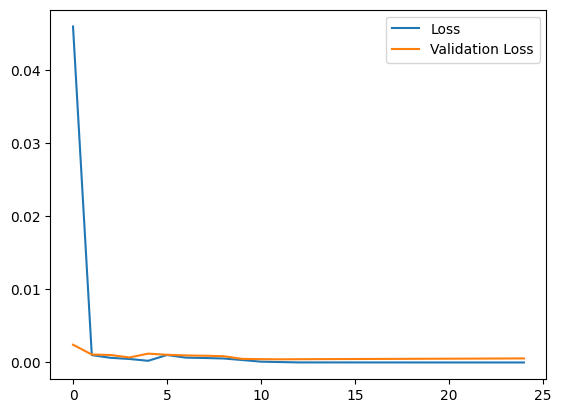

In [64]:

import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

In [65]:
model.save("/kaggle/working/ids_model.keras")

In [66]:
import json
import joblib


if 'reference_columns' in locals():
    feature_names = list(reference_columns)
else:
    
    feature_names = list(df_sample.columns.drop('Label'))

print(f"Found {len(feature_names)} Feature Names:")
print(feature_names)


class_names = list(le.classes_)
print(f"\nFound {len(class_names)} Class Names:")
print(class_names)


# 3. SAVE 



with open('model_columns.json', 'w') as f:
    json.dump(feature_names, f)
print("\nSaved 'model_columns.json'")


joblib.dump(le, 'label_encoder.joblib')
print("Saved 'label_encoder.joblib'")


joblib.dump(scaler, 'scaler.joblib')
print("Saved 'scaler.joblib'")


model.save('ids_model.keras')
print("Saved 'ids_model.keras'")

Found 78 Feature Names:
['Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Av

In [67]:
print(len(X_train), len(X_test))

80000 20000


In [68]:
import numpy as np
from sklearn.metrics import classification_report, f1_score

print("      FINAL EVALUATION: LEFTOVER TRAFFIC          ")


print("Evaluating overall performance on leftover data...")
results = model.evaluate(leftover_ds, verbose=1)

print(f"\nLeftover Traffic Loss: {results[0]:.4f}")
print(f"Leftover Traffic Accuracy: {results[1]:.4f}")


print("\nGenerating detailed predictions...")
predictions = model.predict(leftover_ds)

predicted_classes = np.argmax(predictions, axis=1)


macro_f1 = f1_score(y_leftover_enc, predicted_classes, average='macro')
weighted_f1 = f1_score(y_leftover_enc, predicted_classes, average='weighted')

print(f"Leftover Traffic Macro F1: {macro_f1:.4f}")
print(f"Leftover Traffic Weighted F1: {weighted_f1:.4f}")

print("\n--- Detailed Classification Report (Leftover Data) ---")
print(classification_report(y_leftover_enc, predicted_classes, target_names=le.classes_))

      FINAL EVALUATION: LEFTOVER TRAFFIC          
Evaluating overall performance on leftover data...
1853/1853 ━━━━━━━━━━━━━━━━━━━━ 144s 77ms/step - accuracy: 0.9999 - loss: 0.0012

Leftover Traffic Loss: 0.0002
Leftover Traffic Accuracy: 1.0000

Generating detailed predictions...
1853/1853 ━━━━━━━━━━━━━━━━━━━━ 141s 76ms/step
Leftover Traffic Macro F1: 0.9995
Leftover Traffic Weighted F1: 1.0000

--- Detailed Classification Report (Leftover Data) ---
                      precision    recall  f1-score   support

              Benign       1.00      1.00      1.00    326644
    DDOS attack-HOIC       1.00      1.00      1.00    620369
DDOS attack-LOIC-UDP       1.00      1.00      1.00      1562

            accuracy                           1.00    948575
           macro avg       1.00      1.00      1.00    948575
        weighted avg       1.00      1.00      1.00    948575



In [70]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

print("Calculating predictions for all splits (Train, Test, Leftover)...")

train_probs = model.predict(X_train, batch_size=BATCH_SIZE)
train_preds = np.argmax(train_probs, axis=1)
train_acc = accuracy_score(y_train, train_preds)
train_f1 = f1_score(y_train, train_preds, average='macro')

test_probs = model.predict(X_test, batch_size=BATCH_SIZE)
test_preds = np.argmax(test_probs, axis=1)
test_acc = accuracy_score(y_test, test_preds)
test_f1 = f1_score(y_test, test_preds, average='macro')

leftover_probs = model.predict(X_leftover_scaled, batch_size=BATCH_SIZE)
leftover_preds = np.argmax(leftover_probs, axis=1)
leftover_acc = accuracy_score(y_leftover_enc, leftover_preds)
leftover_f1 = f1_score(y_leftover_enc, leftover_preds, average='macro')

total_leftover = len(leftover_df)
leftover_counts = leftover_df['Label'].value_counts()

benign_leftover = leftover_counts.get('Benign', 0)
malicious_leftover = total_leftover - benign_leftover 

benign_leftover_pct = (benign_leftover / total_leftover) * 100
malicious_leftover_pct = (malicious_leftover / total_leftover) * 100

summary_data = {
    "Attack Included": ["DDOSHoic,DDOSLoicUDP"],
    "Train Accuracy": [f"{train_acc:.4f}"],
    "Test Accuracy": [f"{test_acc:.4f}"],
    "Leftover Accuracy": [f"{leftover_acc:.4f}"],
    "Train F1 (Macro)": [f"{train_f1:.4f}"],
    "Test F1 (Macro)": [f"{test_f1:.4f}"],
    "Leftover F1 (Macro)": [f"{leftover_f1:.4f}"],
    "Sampled Instances (Train+Test)": ["100,000"],
    "Split (Train/Test)": ["80% / 20%"],
    "Leftover Instances": [f"{total_leftover:,}"],
    "Leftover Benign %": [f"{benign_leftover_pct:.2f}%"],
    "Leftover Malicious %": [f"{malicious_leftover_pct:.2f}%"]
}

summary_df = pd.DataFrame(summary_data)

display(summary_df)

Calculating predictions for all splits (Train, Test, Leftover)...
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step
1853/1853 ━━━━━━━━━━━━━━━━━━━━ 139s 75ms/step


,Attack Included,Train Accuracy,Test Accuracy,Leftover Accuracy,Train F1 (Macro),Test F1 (Macro),Leftover F1 (Macro),Sampled Instances (Train+Test),Split (Train/Test),Leftover Instances,Leftover Benign %,Leftover Malicious %
0,"DDOSHoic,DDOSLoicUDP",1.0000,1.0000,1.0000,1.0000,1.0000,0.9995,"100,000",80% / 20%,"948,575",34.44%,65.56%
